In [1]:
# IMPORT LIBRARIES
import os
import glob

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pyleoclim as pyleo


from mpl_toolkits.basemap import Basemap

##### Data for FIgure 1 plot: 
https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-single-levels-monthly-means?tab=overview
> used CAPE, Convective precipitation, Total Precipitation and Wind Speed data (1940-2023)
> extracted subregion : 20 - 0 N and 10 W - 130 E
> Data lives in the External Hardrive
> https://dwikita-ichsana.medium.com/meteorology-101-how-to-plot-wind-map-e43c196edce8

In [2]:
### PATHS #####
cave_path = 'Data/Caves/' 
inst_path = 'Data/Instrumental/'
save_path = 'Figures/GRL_Figures/'

#### SITE NAMES ####
P_site_name = [ 'chocfountain_stalagmate.csv', 'stumpy_stalagmate.csv', 
             'twins_stalagmate.csv', 'goblin_stalagmate.csv', 
             'chocfountain_hobo.csv', 'Stumpy_hobo.csv', 'goblin_hobo.csv', 'Vaisala.csv' ]


B_site_name = [ 'stal_slow.csv','stal_fast.csv', 'hobo_entrance.csv', 
               'hobo_interior.csv','Vaisala_Bulacan_.csv'  ]

#### WEATHER STATION SITES ###### 
weather_sites = [ 'CLSU.csv', 'Puerto.csv','Aparri.csv' ]

def cave_daily( cave_name, site_name ):
    ''''
        This function reads drip rate data and converts it to daily data
        Input = cave name and associated cave site, raw drip rate
        Output= Daily time and daily drip rate in units of ml/min
        
    '''
    df_path    = os.path.join( cave_path, cave_name, site_name)
    df         = pd.read_csv( df_path )
    df.dropna( subset=['Time'], inplace=True )
    df['Time'] = pd.to_datetime( df['Time'], format = '%m/%d/%y %H:%M' )
    df.set_index( 'Time', inplace = True )
    df_daily   = df.resample('D').mean().reset_index( names = 'Date' )
    return df_daily

def inst_data(station):
    '''
    Functioon reads in daily weather station data from the Philippines
    input = raw weather station data closest to cave and in the same climate type
    output = parsed out daily data for variables: precip, temp, pressure, wind speed, wind direction
    '''
    inst    = os.path.join( inst_path,station)
    df_inst = pd.read_csv( inst, na_values=['-999'], parse_dates = { 'Date': ['YEAR', 'MONTH','DAY'] } )
    return df_inst



In [3]:
### WEATHER STATION DATA #####
df_clsu   = inst_data(weather_sites[0])
df_puerto = inst_data(weather_sites[1])
df_aparri = inst_data(weather_sites[2])

###### DAILY CAVE DATA #########
### Puerto Princesa ###
'Drip Rate'
df_cf_daily     = cave_daily('Palawan', P_site_name[0])
df_stumpy_daily = cave_daily('Palawan', P_site_name[1])
df_twins_daily  = cave_daily('Palawan', P_site_name[2])
df_goblin_daily = cave_daily('Palawan', P_site_name[3])
'Cave-Air Temperature'
df_chocf_daily  = cave_daily('Palawan', P_site_name[4])
df_st_daily     = cave_daily('Palawan', P_site_name[5])
df_gob_daily    = cave_daily('Palawan', P_site_name[6])
'Cave-Air CO2'
df_pal_co2_daily= cave_daily('Palawan', P_site_name[7])

### Biak-Na-Bato/Bulacan ###
'Drip Rate'
df_slow_daily = cave_daily('Bulacan', B_site_name[0])
df_fast_daily = cave_daily('Bulacan', B_site_name[1])
'Cave-Air Temperature'
df_entra_daily= cave_daily('Bulacan', B_site_name[2])
df_inte_daily = cave_daily('Bulacan', B_site_name[3])
'Cave-Air CO2'
df_bnb_co2_daily=cave_daily('Bulacan', B_site_name[4])


/var/folders/cm/syqd5kfn0xl_t2hqr3m3szhc0000gn/T/ipykernel_90955/4090127407.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  orig_map=plt.cm.get_cmap('ocean')


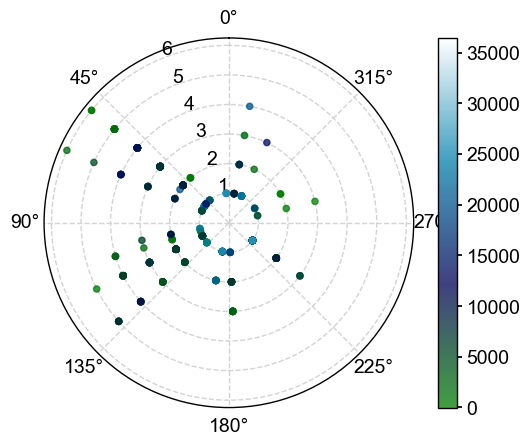

In [4]:
# POLAR PROJECTION 
r     = df_clsu['WIND_SPEED'][222:719]
theta = df_clsu['WIND_DIRECTION'][222:719] # OVERLAP with CO2
values= df_bnb_co2_daily['CO2']

# Compute areas and colors

colors = values
orig_map=plt.cm.get_cmap('ocean') 
  
# reversing the original colormap using reversed() function 
reversed_map = orig_map.reversed() 
fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')
c = ax.scatter(theta, r, c=values, s=20, cmap='ocean' , alpha=0.75)
ax.set_theta_zero_location("N")
#c = ax.scatter(theta, r, c=values, s=20, cmap=reversed_map , alpha=0.75)
fig.colorbar(c)
plt.savefig(os.path.join(save_path, 'Wind_Rose.eps'))

<BarContainer object of 730 artists>

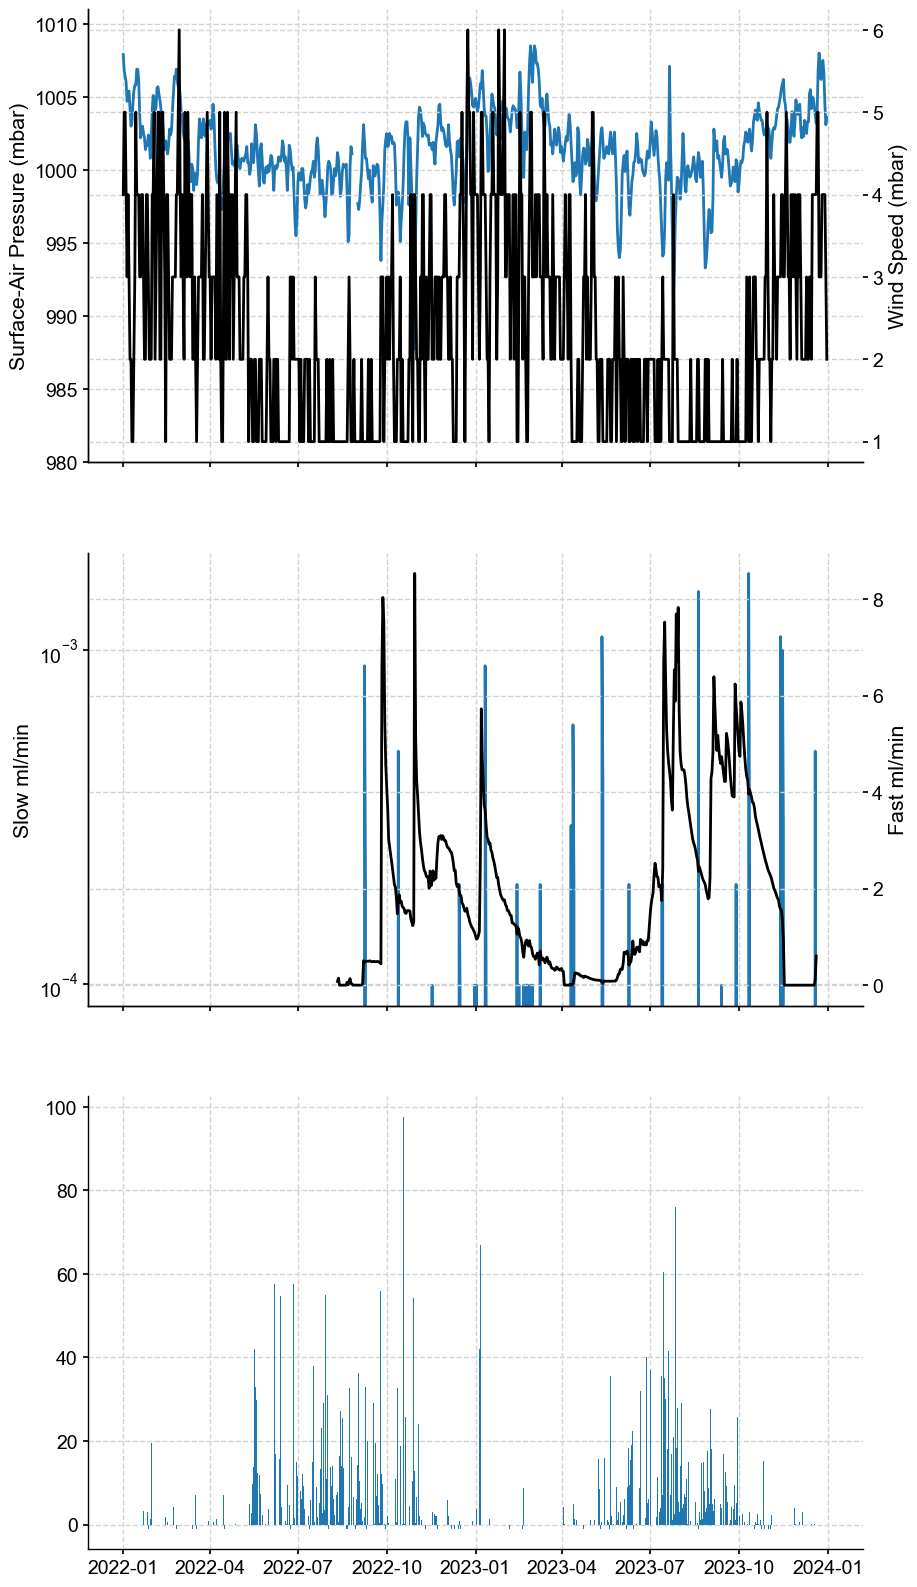

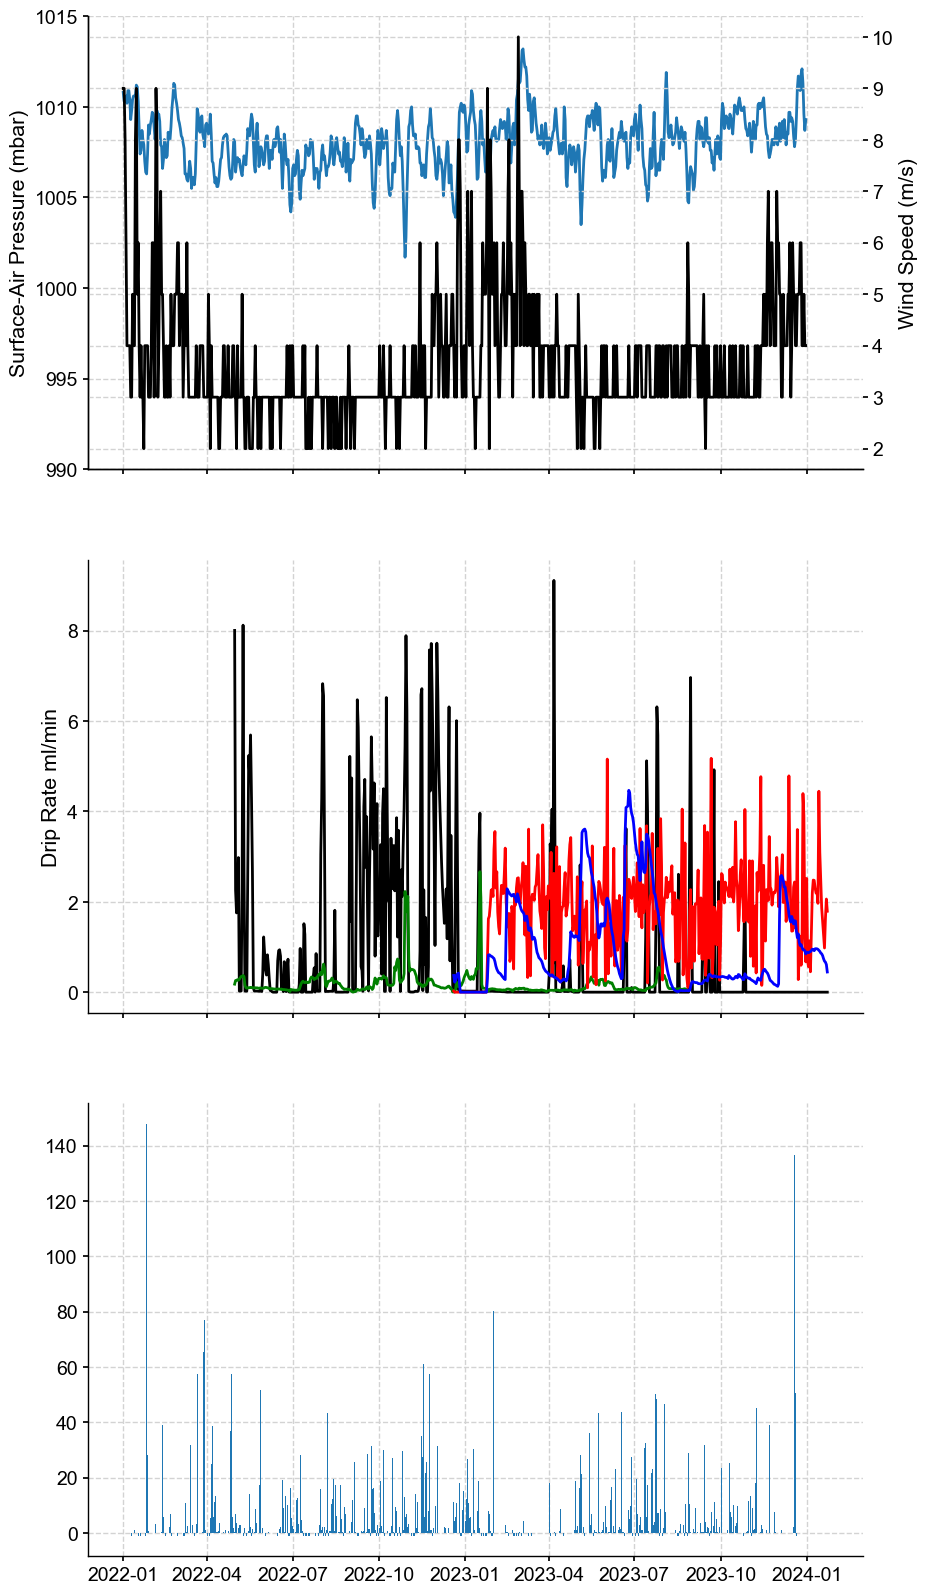

In [5]:
### FIGURE DRIP RATE AND WEATHER STATION DATA FOR BIAK NA BATO ###
f, (ax1, ax3, ax5) = plt.subplots( 3, 1, figsize = (10,20), sharex = True ) 
ax1.plot( df_clsu['Date'], df_clsu['PRESSURE'])
ax1.set_ylabel('Surface-Air Pressure (mbar)')
ax1.set_ylim( [980, 1011])
ax2 = ax1.twinx()
ax2.plot( df_clsu['Date'], df_clsu['WIND_SPEED'], 'k')
ax2.set_ylabel('Wind Speed (mbar)')
ax3.plot( df_slow_daily['Date'], df_slow_daily['slow_ml/min'])
ax3.set_yscale('log')
ax3.set_ylabel('Slow ml/min')
ax4 = ax3.twinx()
ax4.plot( df_fast_daily['Date'], df_fast_daily['fast_ml/min'], 'k')
ax4.set_ylabel('Fast ml/min')
ax5.bar( df_clsu['Date'], df_clsu['RAINFALL'], width = 1)
#plt.savefig(os.path.join(save_path, 'BNB.eps'))

### FIGURE DRIP RATE AND WEATHER STATION DATA FOR PUERTO PRINCESA ###
f, (ax1, ax3, ax5) = plt.subplots( 3, 1, figsize = (10,20), sharex = True ) 
ax1.plot( df_puerto['Date'], df_puerto['PRESSURE'])
ax1.set_ylabel('Surface-Air Pressure (mbar)')
ax1.set_ylim( [990, 1015])
ax2 = ax1.twinx()
ax2.plot( df_puerto['Date'], df_puerto['WIND_SPEED'], 'k')
ax2.set_ylabel('Wind Speed (m/s)')
ax3.plot( df_cf_daily['Date'], df_cf_daily['cf_ml/min'], 'k')
ax3.plot( df_stumpy_daily['Date'], df_stumpy_daily['stumpy_ml/min'], 'g')
ax3.plot( df_twins_daily['Date'], df_twins_daily['twins_ml/min'], 'r')
ax3.plot( df_goblin_daily['Date'], df_goblin_daily['goblin_ml/min'], 'b')
ax3.set_ylabel('Drip Rate ml/min')
ax5.bar( df_puerto['Date'], df_puerto['RAINFALL'], width = 1)
#plt.savefig(os.path.join(save_path, 'Puerto.eps'))

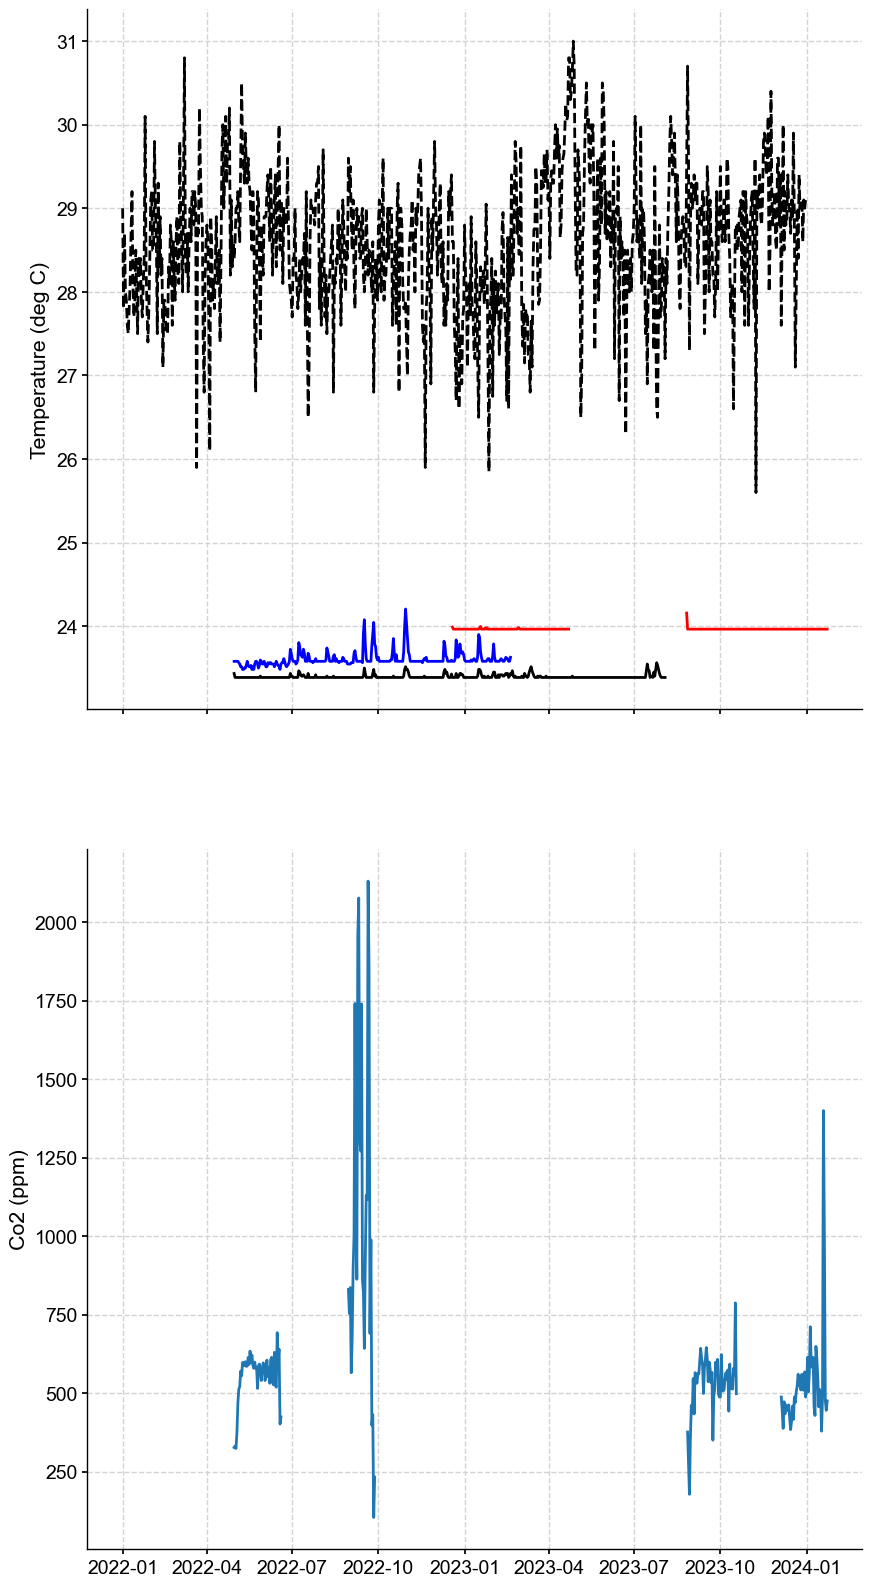

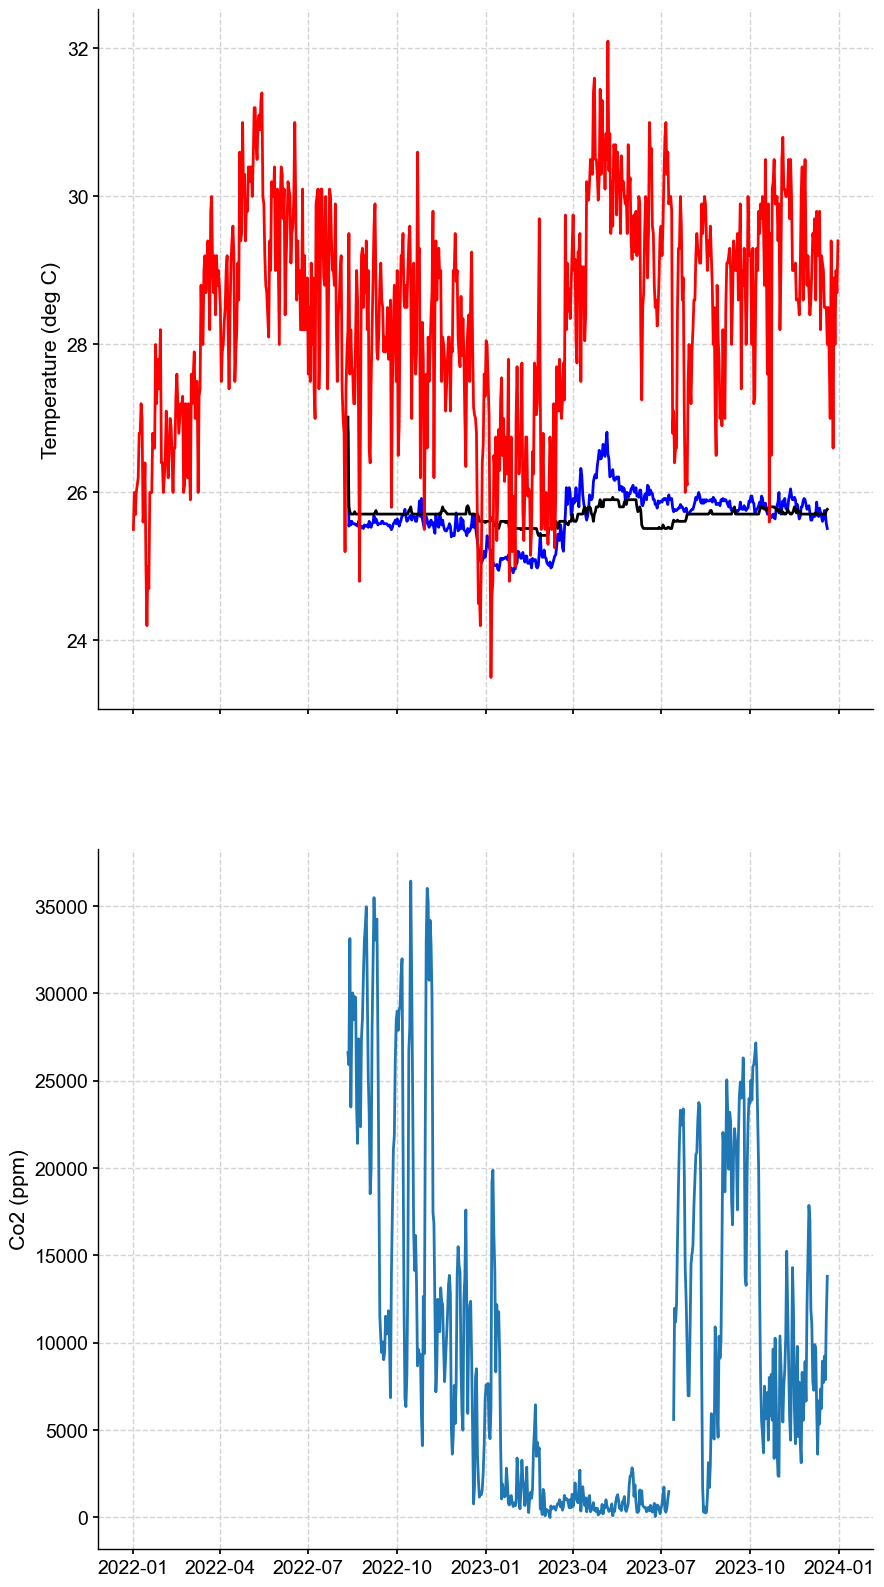

In [6]:
##### PLOT TEMP and CO2 for PALAWAN #####
f, (ax1, ax2) = plt.subplots( 2, 1, figsize = (10,20), sharex = True ) 
ax1.plot( df_chocf_daily['Date'], df_chocf_daily['CF_Temp'],'b')
ax1.plot( df_st_daily['Date'], df_st_daily['Stumpy_Temp'],'k')
ax1.plot( df_gob_daily['Date'], df_gob_daily['Goblin_Temp'],'r')
ax1.plot()
ax1.plot( df_puerto['Date'], df_puerto['TMEAN'],'k--')
ax1.set_ylabel('Temperature (deg C)')
ax2.plot( df_pal_co2_daily['Date'], df_pal_co2_daily['ppm'])
ax2.set_ylabel('Co2 (ppm)')
plt.savefig(os.path.join(save_path, 'temp_CO2_palawan.eps'))
plt.show()
### CO2 and temperature for Biak Na Bato #####
f, (ax1, ax2) = plt.subplots( 2, 1, figsize = (10,20), sharex = True ) 
ax1.plot( df_entra_daily['Date'], df_entra_daily['Entrance_Temp'],'b')
ax1.plot( df_inte_daily['Date'], df_inte_daily['Interior_Temp'],'k')
ax1.plot( df_clsu['Date'], df_clsu['TMEAN'],'r')
ax1.set_ylabel('Temperature (deg C)')
ax2.plot( df_bnb_co2_daily['Date'], df_bnb_co2_daily['CO2'])
ax2.set_ylabel('Co2 (ppm)')
#plt.savefig(os.path.join(save_path, 'temp_cCO.eps'))
plt.show()

In [5]:
#### CLIMATOLOGY MAPS USING ERA
data = xr.open_dataset('/Users/natashasekhon/Downloads/ERA5.nc')

lat = data.latitude
lon = data.longitude
tp  = data.tp
### LONGITUDE FOR PHILIPPINES
tp_phili = tp[:,0:61,420:481]
wind_u = data.u10
wind_u_phili = wind_u[:,0:61,420:481]
wind_v = data.v10
wind_v_phili = wind_v[:,0:61,420:481]


In [150]:
uset_by_season = wind_u.groupby('time.season').mean('time')
u_range = ( ( uset_by_season.sel(season='MAM') ) )

vset_by_season = wind_v.groupby('time.season').mean('time')
v_range = ( ( vset_by_season.sel(season='MAM') ) )

WS = np.sqrt(wind_u**2 + wind_v**2)

dset_by_season = tp_phili.groupby('time.season').sum('time')
tmp_range = ( ( ( dset_by_season.sel(season='MAM') ) ) * 1000 )/3# m to mm
tmp_range.max()

/var/folders/cm/syqd5kfn0xl_t2hqr3m3szhc0000gn/T/ipykernel_27638/1754559445.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  orig_map=plt.cm.get_cmap('terrain')


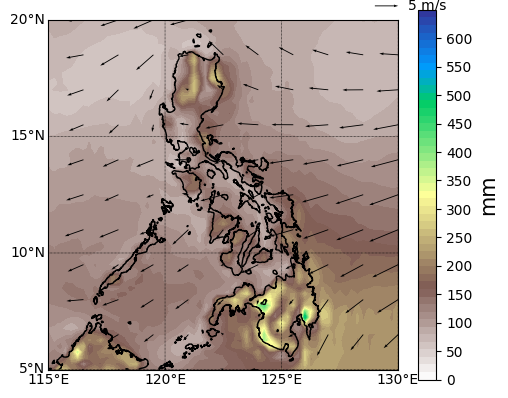

In [246]:
m = Basemap(projection='cyl', llcrnrlon=115, llcrnrlat=5, urcrnrlon=130, urcrnrlat=20, resolution='h')
m.drawcoastlines(1)
m.drawcountries(1)

### Latitude ###
parallels = np.arange(-20,20+0.15,5)
m.drawparallels(parallels, labels=[1,0,0,0], linewidth=0.5)
### Longitude ###
meridians = np.arange(115,130+0.25,5)
m.drawmeridians(meridians, labels=[0,0,0,1], linewidth=0.5)

#### Countour ####
orig_map=plt.cm.get_cmap('terrain') 
  
# reversing the original colormap using reversed() function 
reversed_map = orig_map.reversed() 
levels = np.linspace(0,650,50)
#cf = plt.contourf(lon,lat,tmp_range, levels = levels, cmap=reversed_map) ### going from m/day to mm/day
cf = plt.contourf(lon[420:481],lat[0:61],tmp_range, levels = levels, cmap=reversed_map ) ### going from m/day to mm/day
Q = plt.quiver(lon[::6],lat[::6],wind_u[3,::6,::6],wind_v[3,::6,::6], scale_units='xy', scale=5, width=0.0025)
# 1 for F; 3 for april; 6 for July; 8 for October

#Q = plt.quiver(lon[::6],lat[::6],wind_u[5,::6,::6],wind_v[5,::6,::6], scale_units='xy', scale=3, width=0.0025)
qk = plt.quiverkey(Q, 1, 1.04, 5,str(5)+' m/s',labelpos='E',coordinates='axes')
cb = plt.colorbar(cf, fraction=0.255, pad=0.04, ticks=range(0, 650, 50) )
cb.set_label('mm',  fontsize=15)
plt.savefig(os.path.join(save_path, 'MAM_V2.eps'))
plt.show()

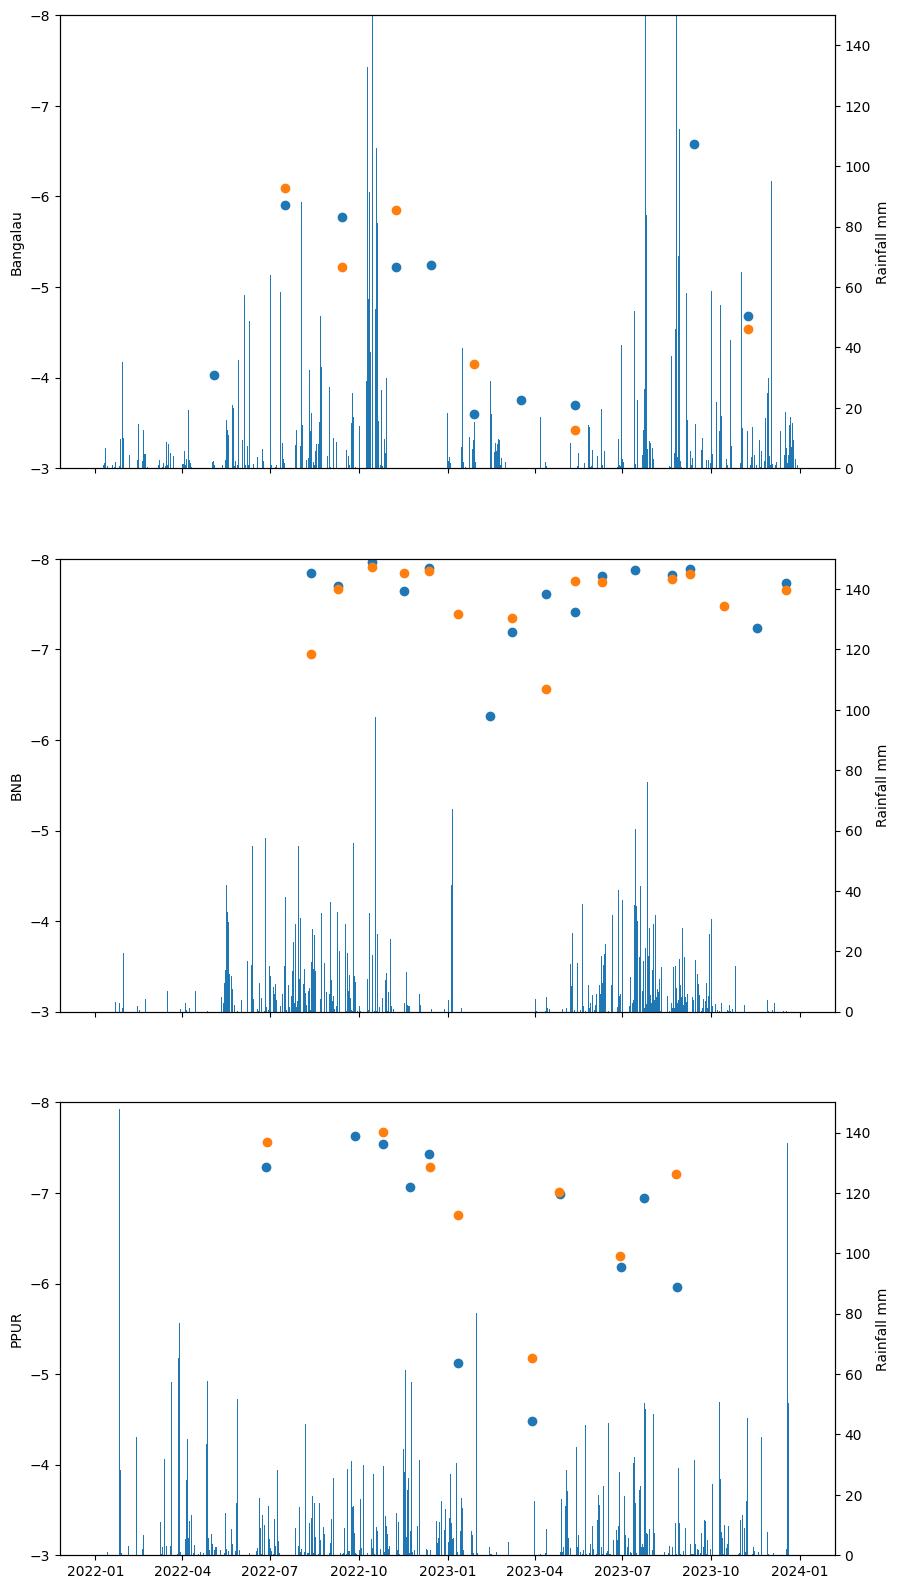

(-3.0, -8.0)

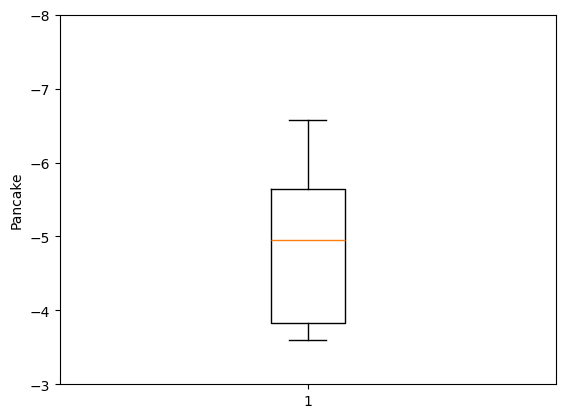

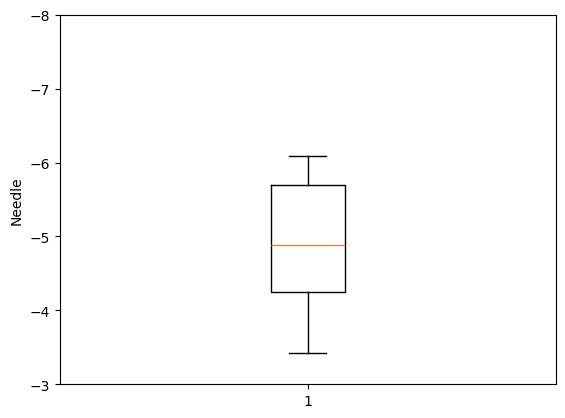

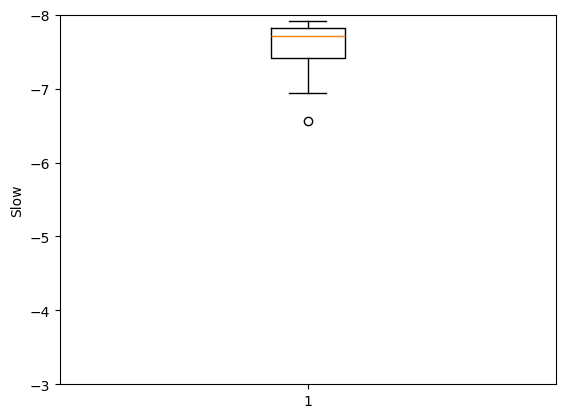

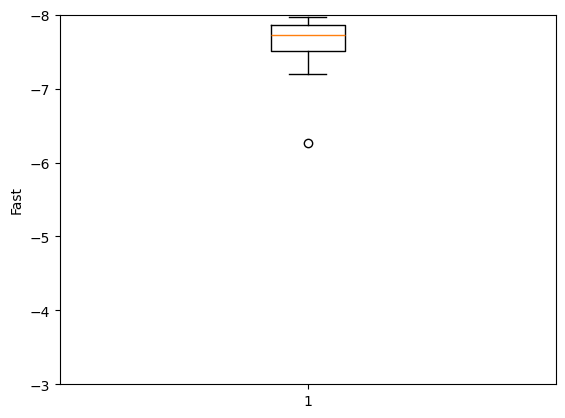

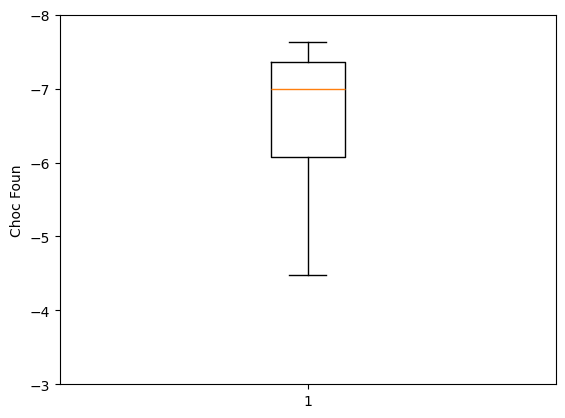

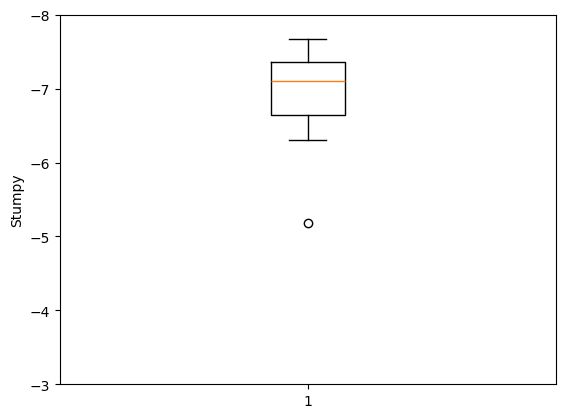

In [12]:
#### FIGURE DRIP WATER TIME SERIES #######
water_stable_path = 'Data/Chemical/stable_iso/water_stable.xlsx'

#### ISOTOPE DATA ######
ppur_iso  = pd.read_excel(water_stable_path, sheet_name='PPUR_IAEA')
banga_iso = pd.read_excel(water_stable_path, sheet_name='Bangalau_IAEA')
bnb_iso   = pd.read_excel(water_stable_path, sheet_name='BNB_IAEA')

#### PIVOT DATA ######
def drip_pivot(cave, parameter):
    iso_stable = pd.pivot_table(cave.reset_index(),index='Date', columns='Site Name', values=parameter)
    return iso_stable

bnb_o18 = drip_pivot(bnb_iso, 'd18o')
bnb_h   = drip_pivot(bnb_iso, 'dH')

ppur_o18 = drip_pivot(ppur_iso, 'd18o')
ppur_h   = drip_pivot(ppur_iso, 'dH')

banga_o18 = drip_pivot(banga_iso, 'd18o')
banga_h   = drip_pivot(banga_iso, 'dH')


#### FIGURE XXXXX ##########
f, (ax1, ax3, ax5) = plt.subplots( 3, 1, figsize = (10,20), sharex = True ) 
ax1.scatter(banga_o18.index,banga_o18['Pancake'].values)
ax1.scatter(banga_o18.index,banga_o18['Needle'].values)
ax1.set_ylim(-8, -3)
ax1.invert_yaxis()
ax1.set_ylabel('Bangalau')
ax2 = ax1.twinx()
ax2.bar( df_aparri['Date'], df_aparri['RAINFALL'], width = 1)
ax2.set_ylabel('Rainfall mm')
ax2.set_ylim(0,150)
ax3.scatter(bnb_o18.index,bnb_o18['Fast'].values)
ax3.scatter(bnb_o18.index,bnb_o18['Slow'].values)
ax3.set_ylabel('BNB')
ax3.set_ylim(-8,-3)
ax3.invert_yaxis()
ax4 = ax3.twinx()
ax4.bar( df_clsu['Date'], df_clsu['RAINFALL'], width = 1)
ax4.set_ylabel('Rainfall mm')
ax4.set_ylim(0,150)
ax5.scatter(ppur_o18.index,ppur_o18['Chocolate Fountain'].values)
ax5.scatter(ppur_o18.index,ppur_o18['Stumpy'].values)
ax5.set_ylabel('PPUR')
ax5.set_ylim(-8,-3)
ax5.invert_yaxis()
ax6 = ax5.twinx()
ax6.bar( df_puerto['Date'], df_puerto['RAINFALL'], width = 1)
ax6.set_ylabel('Rainfall mm')
ax6.set_ylim(0,150)
#plt.savefig(os.path.join(save_path, 'rain_d18o.eps'))
plt.show()

### BOX PLOT ######
fig, ax = plt.subplots()
ax.boxplot(banga_o18['Pancake'].values[~np.isnan(banga_o18['Pancake'].values)])
ax.invert_yaxis()
ax.set_ylabel('Pancake')
ax.set_ylim(-3, -8)
#plt.savefig(os.path.join(save_path, 'pancake_box.eps'))

fig, ax = plt.subplots()
ax.boxplot(banga_o18['Needle'].values[~np.isnan(banga_o18['Needle'].values)])
ax.invert_yaxis()
ax.set_ylabel('Needle')
ax.set_ylim(-3, -8)
#plt.savefig(os.path.join(save_path, 'needle_box.eps'))

fig, ax = plt.subplots()
ax.boxplot(bnb_o18['Slow'].values[~np.isnan(bnb_o18['Slow'].values)])
ax.invert_yaxis()
ax.set_ylabel('Slow')
ax.set_ylim(-3, -8)
#plt.savefig(os.path.join(save_path, 'slow_box.eps'))

fig, ax = plt.subplots()
ax.boxplot(bnb_o18['Fast'].values[~np.isnan(bnb_o18['Fast'].values)])
ax.invert_yaxis()
ax.set_ylabel('Fast')
ax.set_ylim(-3, -8)
#plt.savefig(os.path.join(save_path, 'fast_box.eps'))

fig, ax = plt.subplots()
ax.boxplot(ppur_o18['Chocolate Fountain'].values[~np.isnan(ppur_o18['Chocolate Fountain'].values)])
ax.invert_yaxis()
ax.set_ylabel('Choc Foun')
ax.set_ylim(-3, -8)
#plt.savefig(os.path.join(save_path, 'choc_box.eps'))

fig, ax = plt.subplots()
ax.boxplot(ppur_o18['Stumpy'].values[~np.isnan(ppur_o18['Stumpy'].values)])
ax.invert_yaxis()
ax.set_ylabel('Stumpy')
ax.set_ylim(-3, -8)
#plt.savefig(os.path.join(save_path, 'stumpy_box.eps'))

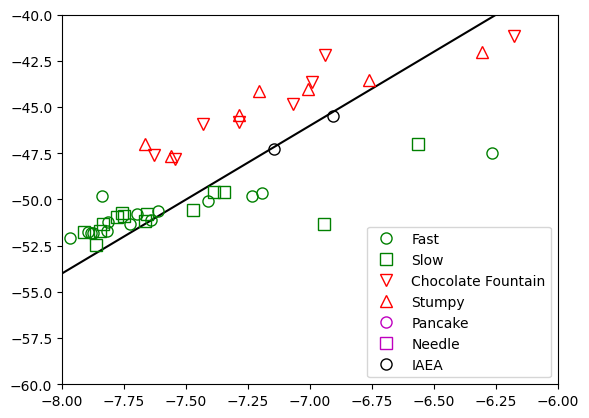

In [13]:
# IAEA GNIP
gmwl_iso  = pd.read_excel(water_stable_path, sheet_name='gmwl')

plt.plot(gmwl_iso['O'], gmwl_iso['D'], color = 'black')

plt.plot(bnb_o18['Fast'].values,bnb_h['Fast'].values, 'go', markerfacecolor = 'none', markersize = 8, label = 'Fast')
plt.plot(bnb_o18['Slow'].values,bnb_h['Slow'].values, 'gs', markerfacecolor = 'none', markersize = 8, label = 'Slow')

plt.plot(ppur_o18['Chocolate Fountain'].values,ppur_h['Chocolate Fountain'].values, 'rv', markerfacecolor = 'none', markersize = 8, label = 'Chocolate Fountain')
plt.plot(ppur_o18['Stumpy'].values,ppur_h['Stumpy'].values, 'r^', markerfacecolor = 'none', markersize = 8, label = 'Stumpy')

plt.plot(banga_o18['Pancake'].values,banga_h['Pancake'].values, 'mo', markerfacecolor = 'none', markersize = 8, label = 'Pancake')
plt.plot(banga_o18['Needle'].values, banga_h['Needle'].values, 'ms', markerfacecolor = 'none', markersize = 8, label = 'Needle')

plt.plot([-3.465833333,-4.126759259,-7.147037037,-6.907407407],[-20.65,-24.54907407,-47.27333333,-45.49953704],'ko',markerfacecolor = 'none', markersize = 8, label = 'IAEA' )
plt.ylim(-60, -40)
plt.xlim(-8, -6)
plt.legend()
plt.show()
#plt.savefig(os.path.join(save_path, 'IAEA.eps'))

/var/folders/cm/syqd5kfn0xl_t2hqr3m3szhc0000gn/T/ipykernel_90955/2533396836.py:5: UserWarning: auto_time_params is not specified. Currently default behavior sets this to True, which might modify your supplied time metadata.  Please set to False if you want a different behavior.
  ts_bul_co2 = pyleo.Series(time=bulacan_CO2['NDate'], value=bulacan_CO2['CO2'],


NaNs have been detected and dropped.
Time axis values sorted in ascending order


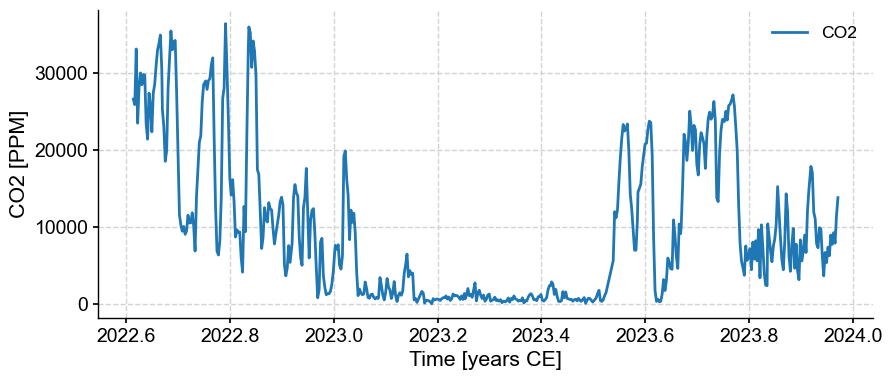

In [6]:
# CO2 data daily for WAVELET ANALYSIS 
bulacan_CO2 = df_bnb_co2_daily
bulacan_CO2['CO2'] = df_bnb_co2_daily['CO2']
bulacan_CO2['NDate'] = df_bnb_co2_daily['Date'].map(lambda  x: x.year + ( (x.month-1)/12) + x.day/365  )
ts_bul_co2 = pyleo.Series(time=bulacan_CO2['NDate'], value=bulacan_CO2['CO2'],
                  time_name='Years', value_name='CO2',
                  time_unit='CE', value_unit='PPM',
                  label='CO2', clean_ts=True)
fig, ax      = ts_bul_co2.plot()



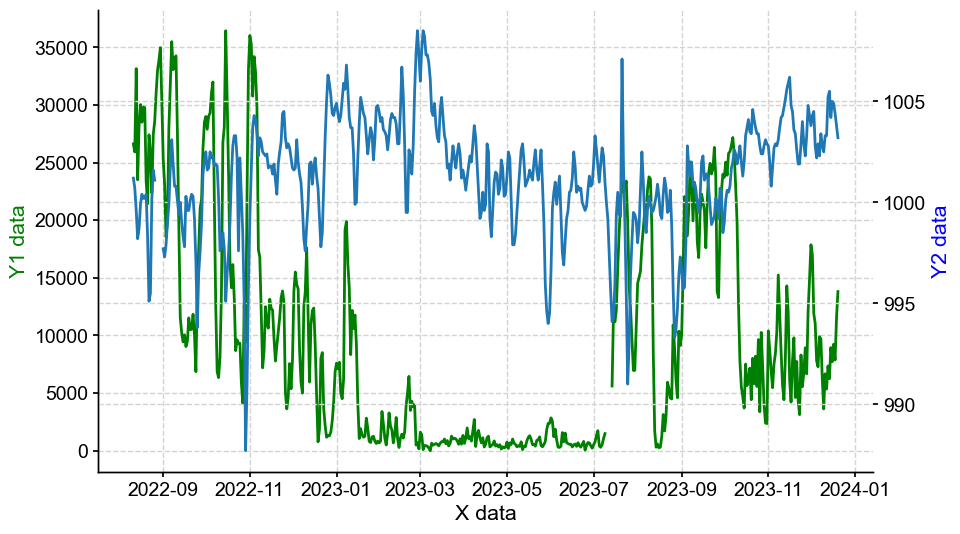

In [24]:

fig, ax1 = plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()
ax1.plot( bulacan_CO2['Date'], bulacan_CO2['CO2'],'g' )
ax2.plot( df_clsu['Date'][222:719], df_clsu['PRESSURE'][222:719] )

ax1.set_xlabel('X data')
ax1.set_ylabel('Y1 data', color='g')
ax2.set_ylabel('Y2 data', color='b')
plt.savefig(os.path.join(save_path, 'Bulacan_CO2.eps'))


/var/folders/cm/syqd5kfn0xl_t2hqr3m3szhc0000gn/T/ipykernel_90955/260562793.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pressure_CO2['Pressure'] = df_clsu['PRESSURE'][222:719]
/var/folders/cm/syqd5kfn0xl_t2hqr3m3szhc0000gn/T/ipykernel_90955/260562793.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pressure_CO2['NDate'] = df_clsu['Date'][222:719].map(lambda  x: x.year + ( (x.month-1)/12) + x.day/365  )
/var/folders/cm/syqd5kfn0xl_t2hqr3m3szhc0000gn/T/ipykernel_90955/260562793.py:5: UserWarning: au

NaNs have been detected and dropped.
Time axis values sorted in ascending order


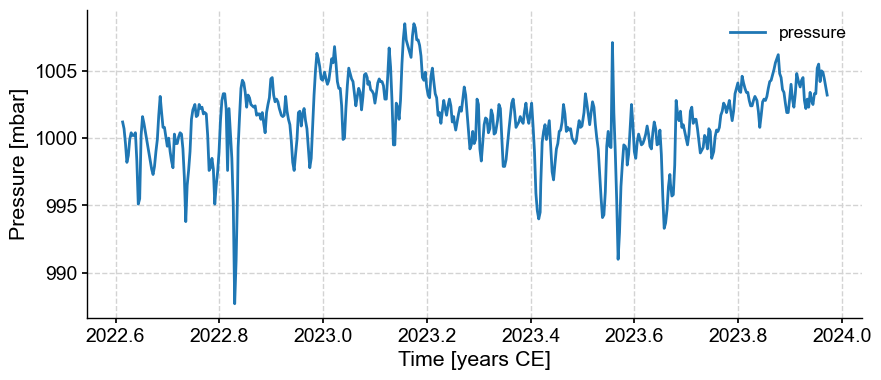

In [8]:
# CO2 data daily for WAVELET ANALYSIS 
pressure_CO2 = df_clsu[222:719]
pressure_CO2['Pressure'] = df_clsu['PRESSURE'][222:719]
pressure_CO2['NDate'] = df_clsu['Date'][222:719].map(lambda  x: x.year + ( (x.month-1)/12) + x.day/365  )
ts_bul_pres = pyleo.Series(time=pressure_CO2['NDate'], value=pressure_CO2['Pressure'],
                  time_name='Years', value_name='Pressure',
                  time_unit='CE', value_unit='mbar',
                  label='pressure', clean_ts=True)
fig, ax      = ts_bul_pres.plot()

In [10]:
# nf = nyquist frequenccy = 0.5 * sampling frequency (daily)
# fmin = 
# fmax = 
# ,freq_kwargs={'fmin':1/365,'fmax':2,'nf':9})

coh = ts_bul_co2.wavelet_coherence(ts_bul_pres)
fig, ax = coh.plot(yticks = [0.01,0.02,0.03, 0.05,0.1, 0.2, 0.5] )
pyleo.utils.plotting.savefig(fig, path=save_path)

Figure saved at: "Figures/GRL_Figures.pdf"


In [13]:
cwt_sig = coh.signif_test(number=20, qs=[.9,.95])

Performing wavelet coherence on surrogate pairs: 100%|█| 20/20 [00:00<00:00, 52.


AttributeError: 'Coherence' object has no attribute 'savefig'

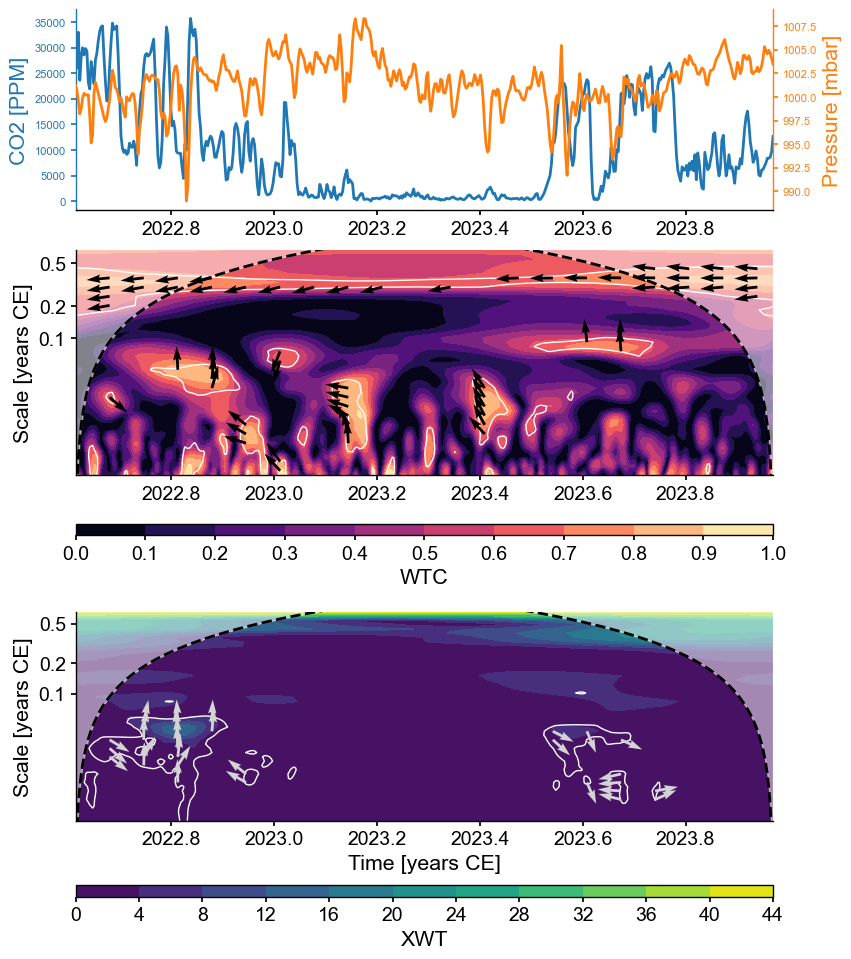

In [18]:
cwt_sig.dashboard()
pyleo.utils.plotting.savefig(cwt_sig, path=save_path)

In [103]:
#ts_bul_co2.detrend(method='savitzky-golay').standardize().wavelet(method='wwz').signif_test(method = 'ar1sim',qs=[0.90]).plot()